### 1. Load Data & Define Settings

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv("/mnt/mjhan/anova-analysis/datasets/renter_survey_long.csv")

group_col = "cluster"
year_col = "year"
metrics = ["age", "happiness", "down_payment"]  # Dependent variables to analyze

### 2. ANOVA & Post-hoc Analysis Functions

In [2]:
# p-value formatting
def format_p(p):
    if p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return "p < 0.01"
    elif p < 0.05:
        return "p < 0.05"
    else:
        return f"p = {p:.3f} (ns)"
    
# ANOVA + Group table
def run_anova(df, dv):

    print("\n" + "="*60)
    print(f"METRIC: {dv}")
    print("="*60)

    # -------------------------
    # 1. Group summary table
    # -------------------------
    group_stats = (
        df.groupby(group_col)[dv]
        .agg(N="count", Mean="mean", SD="std")
        .reset_index()
    )

    group_stats["SE"] = group_stats["SD"] / np.sqrt(group_stats["N"])

    # formatting
    group_stats["Mean"] = group_stats["Mean"].round(2)
    group_stats["SD"] = group_stats["SD"].round(2)
    group_stats["SE"] = group_stats["SE"].round(2)


    print("\n[Group Summary]")
    print(group_stats)

    # -------------------------
    # 2. ANOVA (SciPy)
    # -------------------------
    groups = [g[dv].values for _, g in df.groupby(group_col)]
    F, p = stats.f_oneway(*groups)

    print("\n[ANOVA]")
    print(f"F = {F:.3f}")
    print(f"p = {format_p(p)}")

    # -------------------------
    # 3. Year means table
    # -------------------------
    year_means = (
        df.groupby([year_col, group_col])[dv]
        .mean()
        .unstack()
        
    )

    print("\n[Year Means]")
    print(year_means)

    # -------------------------
    # 4. Plot (Group mean)
    # -------------------------
    plt.style.use("seaborn-v0_8-whitegrid")

    fig, ax = plt.subplots(figsize=(6, 4))

    group_stats.plot(
        x=group_col,
        y="Mean",
        kind="bar",
        yerr="SE",
        legend=False,
        ax=ax,
        color=["#2F5597"]
    )

    ax.set_title(f"{dv} by Cluster")
    ax.set_ylabel(dv)
    ax.set_xlabel("")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    

def posthoc(df, dv):
    tukey = pairwise_tukeyhsd(
        endog=df[dv],
        groups=df[group_col],
        alpha=0.05
    )
    print("\n[Posthoc - Tukey HSD]")
    print(tukey)

### 3. Run ANOVA Analysis for All Metrics


METRIC: age

[Group Summary]
                cluster   N   Mean    SD    SE
0         Active Buyers  18  42.56  2.33  0.55
1  Considering Planning  18  34.89  2.30  0.54
2         Former Buyers  18  64.61  5.24  1.23
3          Not Planning  18  49.67  2.63  0.62
4       Planning Buyers  18  33.44  2.81  0.66

[ANOVA]
F = 275.157
p = p < 0.001

[Year Means]
cluster  Active Buyers  Considering Planning  Former Buyers  Not Planning  \
year                                                                        
Y0           41.833333             35.000000      62.166667     49.333333   
Y1           42.666667             34.666667      66.000000     49.333333   
Y2           43.166667             35.000000      65.666667     50.333333   

cluster  Planning Buyers  
year                      
Y0             32.833333  
Y1             33.500000  
Y2             34.000000  


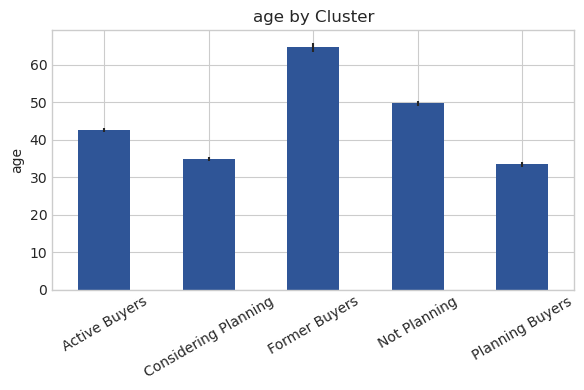


[Posthoc - Tukey HSD]
               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
       group1               group2        meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------------
       Active Buyers Considering Planning  -7.6667    0.0 -10.6914  -4.6419   True
       Active Buyers        Former Buyers  22.0556    0.0  19.0308  25.0803   True
       Active Buyers         Not Planning   7.1111    0.0   4.0864  10.1358   True
       Active Buyers      Planning Buyers  -9.1111    0.0 -12.1358  -6.0864   True
Considering Planning        Former Buyers  29.7222    0.0  26.6975  32.7469   True
Considering Planning         Not Planning  14.7778    0.0  11.7531  17.8025   True
Considering Planning      Planning Buyers  -1.4444 0.6728  -4.4692   1.5803  False
       Former Buyers         Not Planning -14.9444    0.0 -17.9692 -11.9197   True
       Former Buyers      Planning Buyers -31.1667    0.0 -34.19

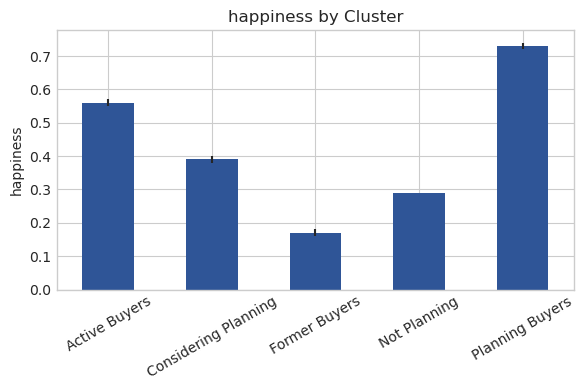


[Posthoc - Tukey HSD]
              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1               group2        meandiff p-adj  lower   upper  reject
-------------------------------------------------------------------------------
       Active Buyers Considering Planning  -0.1667   0.0 -0.1999 -0.1335   True
       Active Buyers        Former Buyers  -0.3828   0.0  -0.416 -0.3496   True
       Active Buyers         Not Planning  -0.2661   0.0 -0.2993 -0.2329   True
       Active Buyers      Planning Buyers   0.1778   0.0  0.1446   0.211   True
Considering Planning        Former Buyers  -0.2161   0.0 -0.2493 -0.1829   True
Considering Planning         Not Planning  -0.0994   0.0 -0.1326 -0.0662   True
Considering Planning      Planning Buyers   0.3444   0.0  0.3112  0.3776   True
       Former Buyers         Not Planning   0.1167   0.0  0.0835  0.1499   True
       Former Buyers      Planning Buyers   0.5606   0.0  0.5274  0.5938   True
        Not Plann

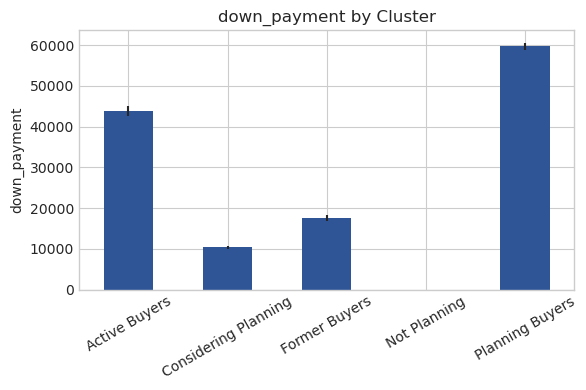


[Posthoc - Tukey HSD]
                   Multiple Comparison of Means - Tukey HSD, FWER=0.05                    
       group1               group2          meandiff  p-adj    lower       upper    reject
------------------------------------------------------------------------------------------
       Active Buyers Considering Planning -33494.4444   0.0 -36504.5635 -30484.3254   True
       Active Buyers        Former Buyers -26166.6667   0.0 -29176.7857 -23156.5476   True
       Active Buyers         Not Planning -43833.3333   0.0 -46843.4524 -40823.2143   True
       Active Buyers      Planning Buyers  15833.3333   0.0  12823.2143  18843.4524   True
Considering Planning        Former Buyers   7327.7778   0.0   4317.6587  10337.8968   True
Considering Planning         Not Planning -10338.8889   0.0 -13349.0079  -7328.7698   True
Considering Planning      Planning Buyers  49327.7778   0.0  46317.6587  52337.8968   True
       Former Buyers         Not Planning -17666.6667   0.0 -20676.

In [3]:
# Run for all metrics
for dv in metrics:
    run_anova(df, dv)
    posthoc(df, dv) 
